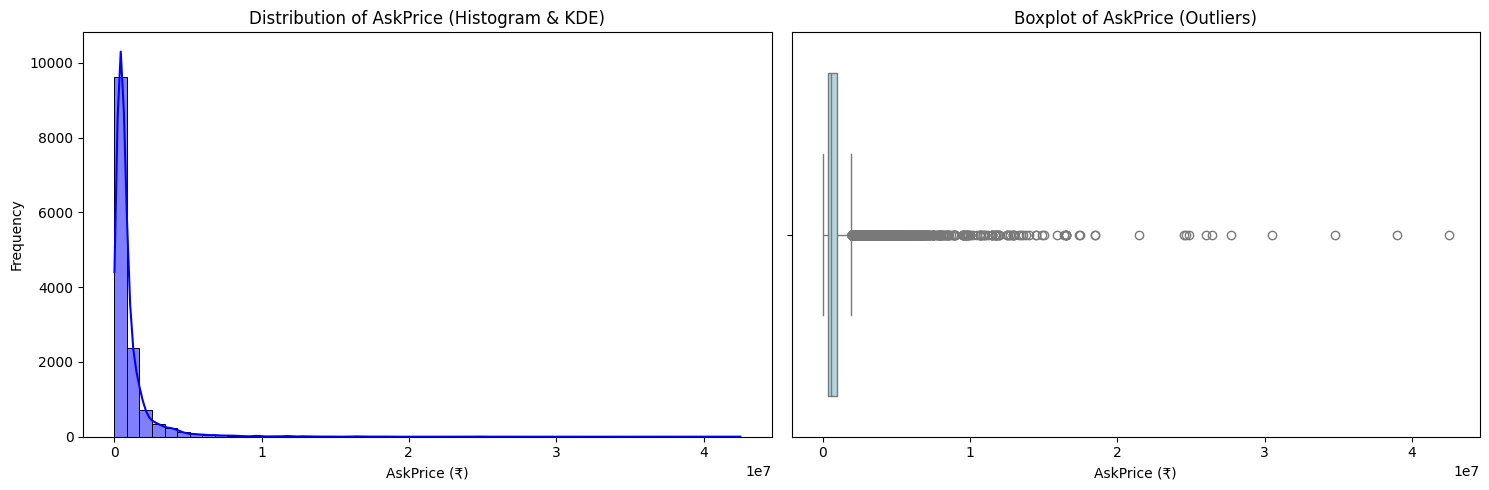

--- AskPrice Statistics ---
Mean:   ₹ 985,186.31
Median: ₹ 560,000.50
Skewness: 8.393


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the cleaned data (assuming notebook is inside the /notebooks directory)
df = pd.read_csv('../data/interim/used_cars_cleaned.csv')

# 2. Set up the matplotlib figure (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 3. Plot Histogram with Kernel Density Estimate (KDE) curve
sns.histplot(df['AskPrice'], kde=True, ax=axes[0], color='blue', bins=50)
axes[0].set_title('Distribution of AskPrice (Histogram & KDE)')
axes[0].set_xlabel('AskPrice (₹)')
axes[0].set_ylabel('Frequency')

# 4. Plot Boxplot to identify outliers
sns.boxplot(x=df['AskPrice'], ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot of AskPrice (Outliers)')
axes[1].set_xlabel('AskPrice (₹)')

# Display the plots
plt.tight_layout()
plt.show()

# 5. Calculate and print summary statistics
mean_price = df['AskPrice'].mean()
median_price = df['AskPrice'].median()
skewness = df['AskPrice'].skew()

print(f"--- AskPrice Statistics ---")
print(f"Mean:   ₹ {mean_price:,.2f}")
print(f"Median: ₹ {median_price:,.2f}")
print(f"Skewness: {skewness:.3f}")

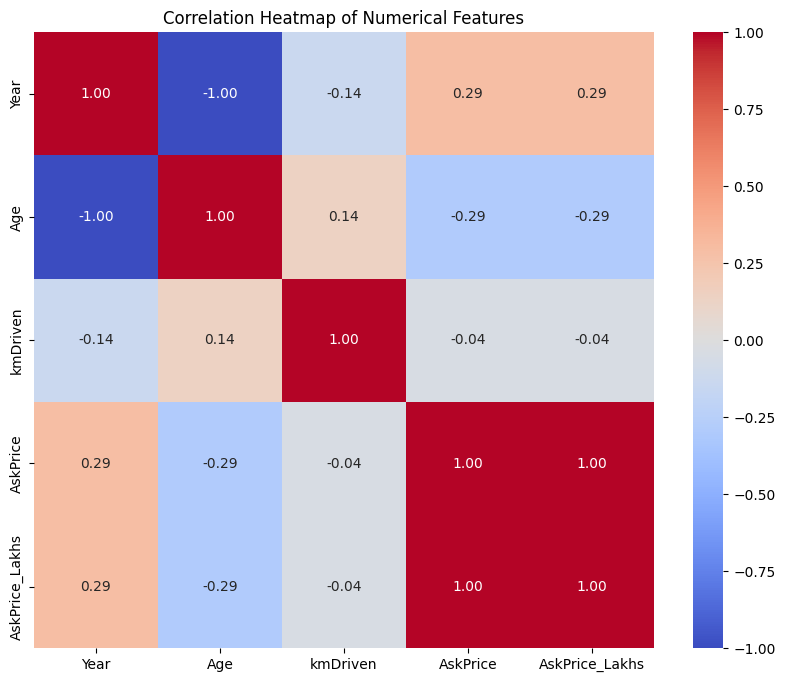

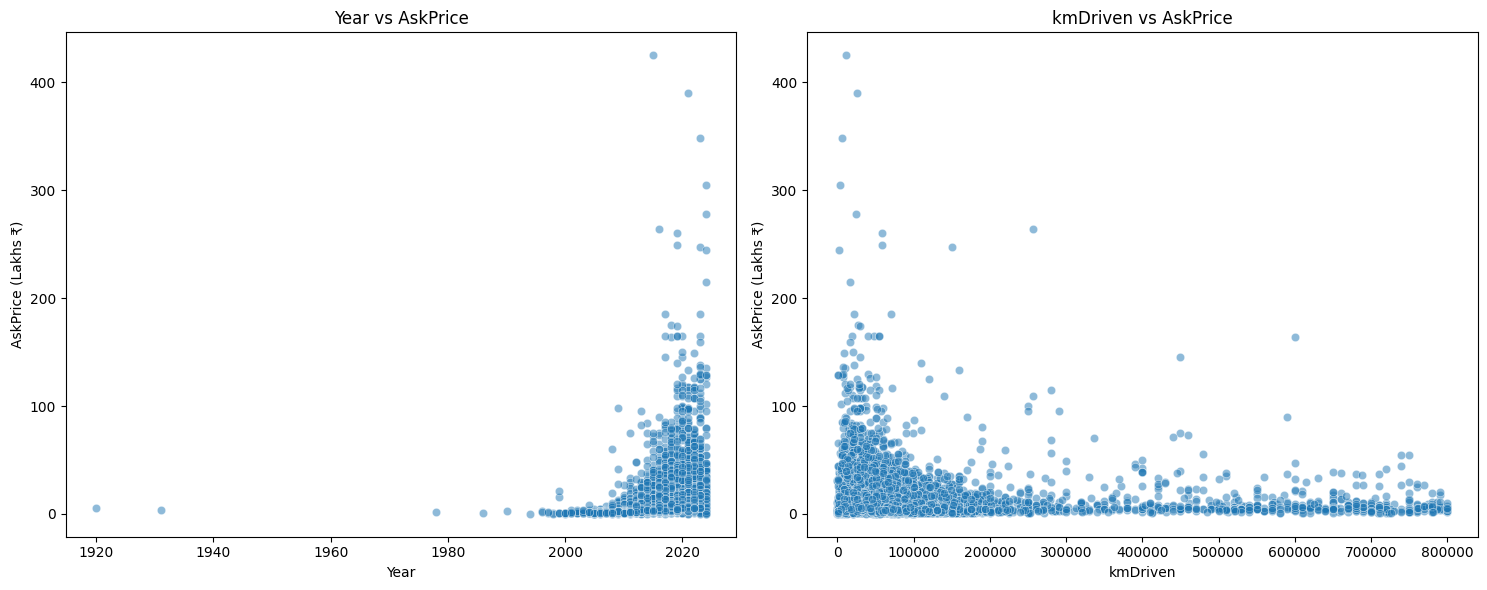

In [2]:
# 1. Filter for numerical columns only
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df_numeric = df[numeric_cols].copy()

# Create a readable target column (Prices in Lakhs)
df_numeric['AskPrice_Lakhs'] = df_numeric['AskPrice'] / 100000

# 2. Calculate the correlation matrix
corr_matrix = df_numeric.corr()

# 3. Plot the Correlation Heatmap
plt.figure(figsize=(10, 8))
# We annotate the heatmap to show the actual correlation scores
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# 4. Plot Scatter Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Year vs AskPrice
sns.scatterplot(data=df_numeric, x='Year', y='AskPrice_Lakhs', ax=axes[0], alpha=0.5)
axes[0].set_title('Year vs AskPrice')
axes[0].set_ylabel('AskPrice (Lakhs ₹)')

# kmDriven vs AskPrice
sns.scatterplot(data=df_numeric, x='kmDriven', y='AskPrice_Lakhs', ax=axes[1], alpha=0.5)
axes[1].set_title('kmDriven vs AskPrice')
axes[1].set_ylabel('AskPrice (Lakhs ₹)')

plt.tight_layout()
plt.show()